### 1. Multispectral Data Acquisition and Feature Engineering

El objetivo de este apartado es la construcción de un dataset mediante la librería **MapMiner**, transformando datos satelitales en indicadores biológicos aptos para el modelado.  

**Estrategia de Muestreo con MapMiner:**  
- ¿Cómo se ha definido la selección de zonas a nivel global?
- ¿De qué manera MapMiner permite pasar de un análisis local a uno de alcance forestal y agrícola a gran escala? 

**Control de Calidad:**   
- ¿Cuál es la condición de descarte de datos para asegurar que el dataset final esté libre de ruido atmosférico?
- ¿En qué criterio se basa esta detección?

**Ingeniería de Características:**
- ¿Cómo se aprovechan los datos del infrarrojo extraídos por MapMiner para detectar anomalías que el ojo humano ignora?
- ¿Por qué se calcula la media y la desviación estándar de cada banda en lugar de usar píxeles individuales?

In [3]:
import os
import numpy as np
import pandas as pd
from mapminer.miners import LandsatMiner
import time
import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE 

In [5]:
inici = time.time()
# ==========================================
# 1. CREACIÓN DE CARPETA
# ==========================================
base_dir = os.path.join("..", "data")
os.makedirs(base_dir, exist_ok=True)

# ==========================================
# 2. BASE DE DATOS 
# ==========================================
def fabricar_puntos(nombre, estado, lat, lon, dispersion, n, fecha):
    lats = np.random.uniform(lat - dispersion, lat + dispersion, n)
    lons = np.random.uniform(lon - dispersion, lon + dispersion, n)
    return [{"id": f"{nombre}_{i}", "lat": lats[i], "lon": lons[i], "estado": estado, "rango": fecha} for i in range(n)]

dataset = []
 
# SANO
dataset += fabricar_puntos("Amazonas_Manaus_BR", "sano", -3.10, -60.02, 0.05, 25, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Congo_Basin_COG", "sano", -1.50, 18.00, 0.05, 25, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Borneo_Forest_IDN", "sano", 0.00, 114.00, 0.05, 25, "2024-05-01/2024-05-15")
dataset += fabricar_puntos("Taiga_Siberia_RUS", "sano", 60.00, 100.00, 0.05, 25, "2024-07-15/2024-07-30")
dataset += fabricar_puntos("British_Columbia_CAN", "sano", 55.00, -125.00, 0.05, 25, "2024-06-15/2024-06-30")
dataset += fabricar_puntos("Olympic_Forest_USA", "sano", 47.80, -123.50, 0.05, 25, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Selva_Irati_ESP", "sano", 42.98, -1.11, 0.05, 25, "2024-08-20/2024-08-30")
dataset += fabricar_puntos("Schwarzwald_GER", "sano", 48.00, 8.20, 0.05, 25, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Aokigahara_JPN", "sano", 35.47, 138.64, 0.05, 25, "2024-05-15/2024-05-30")
dataset += fabricar_puntos("Fiordland_NZL", "sano", -45.00, 167.50, 0.05, 25, "2024-01-15/2024-01-30")
dataset += fabricar_puntos("Yosemite_USA", "sano", 37.86, -119.53, 0.05, 25, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Appalachian_USA", "sano", 36.00, -82.00, 0.05, 25, "2024-06-15/2024-06-30")
dataset += fabricar_puntos("Valdivian_CHI", "sano", -39.80, -73.20, 0.05, 25, "2024-02-01/2024-02-15")
dataset += fabricar_puntos("Tasmania_AUS", "sano", -42.00, 146.50, 0.05, 25, "2024-01-01/2024-01-15")
dataset += fabricar_puntos("Daintree_AUS", "sano", -16.17, 145.41, 0.05, 25, "2024-04-01/2024-04-15")
dataset += fabricar_puntos("Western_Ghats_IND", "sano", 10.00, 77.00, 0.05, 25, "2024-11-01/2024-11-15")
dataset += fabricar_puntos("Guanacaste_CRC", "sano", 10.80, -85.60, 0.05, 25, "2024-12-01/2024-12-15")
dataset += fabricar_puntos("Bialowieza_POL", "sano", 52.70, 23.80, 0.05, 25, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Vicentina_POR", "sano", 37.50, -8.80, 0.05, 25, "2024-05-01/2024-05-15")
dataset += fabricar_puntos("Kruger_ZAF", "sano", -24.00, 31.50, 0.05, 25, "2024-02-01/2024-02-15")

# SEQUÍA
dataset += fabricar_puntos("Sau_ESP_2023", "enfermo_sequia", 41.97, 2.39, 0.04, 20, "2023-04-15/2023-04-30")
dataset += fabricar_puntos("Po_River_ITA", "enfermo_sequia", 45.05, 9.80, 0.04, 20, "2022-07-15/2022-07-30")
dataset += fabricar_puntos("Doñana_ESP_2023", "enfermo_sequia", 37.00, -6.40, 0.04, 20, "2023-05-01/2023-05-15")
dataset += fabricar_puntos("Cape_Town_ZAF", "enfermo_sequia", -33.90, 18.40, 0.04, 20, "2018-02-01/2018-02-15")
dataset += fabricar_puntos("Parana_River_ARG", "enfermo_sequia", -32.50, -60.80, 0.05, 20, "2021-10-01/2021-10-20")
dataset += fabricar_puntos("Jucar_ESP_2024", "enfermo_sequia", 39.20, -1.50, 0.04, 20, "2024-04-01/2024-04-15")
dataset += fabricar_puntos("Central_Valley_USA", "enfermo_sequia", 36.50, -119.50, 0.05, 20, "2021-07-01/2021-07-15")
dataset += fabricar_puntos("Mekong_Delta_VNM", "enfermo_sequia", 10.00, 105.50, 0.05, 20, "2020-04-01/2020-04-15")
dataset += fabricar_puntos("Andalucia_Olivos", "enfermo_sequia", 37.80, -3.80, 0.04, 20, "2023-07-15/2023-07-30")
dataset += fabricar_puntos("Lake_Mead_USA", "enfermo_sequia", 36.01, -114.73, 0.03, 20, "2022-07-20/2022-08-05")
dataset += fabricar_puntos("Chile_Central", "enfermo_sequia", -33.50, -70.80, 0.04, 20, "2022-01-15/2022-02-01")
dataset += fabricar_puntos("Morocco_Wheat", "enfermo_sequia", 33.00, -7.50, 0.05, 20, "2022-03-15/2022-04-01")
dataset += fabricar_puntos("Murray_Darling_AUS", "enfermo_sequia", -34.00, 142.00, 0.05, 20, "2019-12-15/2020-01-01")
dataset += fabricar_puntos("Catalunya_Interior", "enfermo_sequia", 41.50, 1.20, 0.04, 20, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Kansas_Crops", "enfermo_sequia", 38.50, -98.50, 0.05, 20, "2022-08-01/2022-08-15")
dataset += fabricar_puntos("Horn_Africa_ETH", "enfermo_sequia", 7.00, 42.00, 0.05, 20, "2023-01-01/2023-01-30")
dataset += fabricar_puntos("Algarve_POR", "enfermo_sequia", 37.20, -8.00, 0.04, 20, "2023-09-01/2023-09-15")
dataset += fabricar_puntos("Szechuan_CHN", "enfermo_sequia", 30.50, 104.00, 0.05, 20, "2022-08-15/2022-08-30")
dataset += fabricar_puntos("Mexico_North", "enfermo_sequia", 26.00, -105.00, 0.05, 20, "2021-06-15/2021-07-01")
dataset += fabricar_puntos("Madagascar_South", "enfermo_sequia", -24.00, 46.00, 0.05, 20, "2021-11-01/2021-11-15")

# PLAGAS
dataset += fabricar_puntos("Bavaria_Ips_GER", "enfermo_plaga", 49.00, 12.50, 0.05, 20, "2023-07-15/2023-07-30")
dataset += fabricar_puntos("Soria_Pinares_ESP", "enfermo_plaga", 41.80, -2.80, 0.04, 20, "2024-07-10/2024-07-25")
dataset += fabricar_puntos("BC_MountainBeetle_CAN", "enfermo_plaga", 53.50, -124.00, 0.05, 20, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Colorado_Spruce_USA", "enfermo_plaga", 39.00, -106.00, 0.05, 20, "2023-07-20/2023-08-05")
dataset += fabricar_puntos("Scandinavia_BarkBeetle", "enfermo_plaga", 59.50, 15.00, 0.05, 20, "2023-06-15/2023-06-30")
dataset += fabricar_puntos("Xylella_Puglia_ITA", "enfermo_plaga", 40.40, 17.80, 0.03, 20, "2023-06-01/2023-06-15")
dataset += fabricar_puntos("Palm_Weevil_ESP", "enfermo_plaga", 38.30, -0.50, 0.02, 20, "2024-07-01/2024-07-15")
dataset += fabricar_puntos("Emerald_Ash_USA", "enfermo_plaga", 42.00, -83.00, 0.05, 20, "2023-06-20/2023-07-05")
dataset += fabricar_puntos("Pine_Processionary_FRA", "enfermo_plaga", 44.00, 1.00, 0.05, 20, "2024-03-15/2024-04-01")
dataset += fabricar_puntos("Oak_Decline_ESP", "enfermo_plaga", 38.50, -6.50, 0.04, 20, "2023-06-15/2023-06-30")
dataset += fabricar_puntos("Sudden_Oak_Death_USA", "enfermo_plaga", 38.00, -122.50, 0.04, 20, "2023-05-01/2023-05-15")
dataset += fabricar_puntos("Beech_Leaf_Disease_USA", "enfermo_plaga", 41.50, -81.50, 0.05, 20, "2023-06-01/2023-06-15")
dataset += fabricar_puntos("Ash_Dieback_UK", "enfermo_plaga", 52.50, -1.00, 0.05, 20, "2023-07-01/2023-07-15")
dataset += fabricar_puntos("Larch_Disease_NZL", "enfermo_plaga", -45.00, 169.00, 0.05, 20, "2023-01-15/2023-02-01")
dataset += fabricar_puntos("Citrus_Greening_USA", "enfermo_plaga", 28.00, -81.50, 0.04, 20, "2023-11-01/2023-11-15")
dataset += fabricar_puntos("Coffee_Rust_COL", "enfermo_plaga", 5.00, -75.50, 0.03, 20, "2024-02-01/2024-02-15")
dataset += fabricar_puntos("Rubber_Leaf_Fall_THA", "enfermo_plaga", 7.50, 100.00, 0.05, 20, "2024-03-01/2024-03-15")
dataset += fabricar_puntos("Spruce_Budworm_CAN", "enfermo_plaga", 49.00, -68.00, 0.05, 20, "2023-07-01/2023-07-15")
dataset += fabricar_puntos("Dutch_Elm_Disease_NLD", "enfermo_plaga", 52.20, 5.50, 0.05, 20, "2023-06-15/2023-06-30")
dataset += fabricar_puntos("Locust_Swarm_ETH", "enfermo_plaga", 9.50, 42.00, 0.05, 20, "2023-10-01/2023-10-15")

# INCENDIO
dataset += fabricar_puntos("Tenerife_ESP_2023", "incendio", 28.35, -16.50, 0.03, 20, "2023-09-01/2023-09-15")
dataset += fabricar_puntos("Maui_USA_2023", "incendio", 20.88, -156.68, 0.02, 20, "2023-08-20/2023-09-05")
dataset += fabricar_puntos("Chubut_ARG_2024", "incendio", -42.80, -71.40, 0.03, 20, "2024-02-10/2024-02-25")
dataset += fabricar_puntos("Alberta_CAN_2023", "incendio", 55.00, -115.00, 0.05, 20, "2023-06-01/2023-06-15")
dataset += fabricar_puntos("Rodas_GRE_2023", "incendio", 36.10, 27.90, 0.03, 20, "2023-07-20/2023-08-05")
dataset += fabricar_puntos("Castellon_ESP_2023", "incendio", 40.05, -0.60, 0.03, 20, "2023-03-25/2023-04-10")
dataset += fabricar_puntos("NSW_AUS_2020", "incendio", -33.50, 150.30, 0.05, 20, "2020-01-05/2020-01-20")
dataset += fabricar_puntos("Dixie_Fire_USA", "incendio", 40.00, -121.00, 0.05, 20, "2021-08-15/2021-08-30")
dataset += fabricar_puntos("Pedrogao_POR", "incendio", 39.90, -8.20, 0.03, 20, "2017-06-20/2017-07-05")
dataset += fabricar_puntos("Siberia_Yakutia", "incendio", 63.00, 125.00, 0.05, 20, "2021-07-15/2021-08-01")
dataset += fabricar_puntos("Amazonas_PA_BR", "incendio", -3.50, -52.00, 0.04, 20, "2024-08-01/2024-08-15")
dataset += fabricar_puntos("Pantanal_BR", "incendio", -18.00, -56.50, 0.05, 20, "2023-11-15/2023-11-30")
dataset += fabricar_puntos("Valparaiso_CHL", "incendio", -33.10, -71.50, 0.03, 20, "2024-02-01/2024-02-15")
dataset += fabricar_puntos("Corrientes_ARG", "incendio", -28.00, -57.00, 0.04, 20, "2022-02-15/2022-03-01")
dataset += fabricar_puntos("Vilomara_ESP", "incendio", 41.71, 1.87, 0.02, 20, "2022-08-01/2022-08-15")
dataset += fabricar_puntos("Krasnoyarsk_RUS", "incendio", 56.00, 93.00, 0.05, 20, "2022-05-15/2022-05-30")
dataset += fabricar_puntos("Caceres_ESP", "incendio", 40.20, -6.30, 0.03, 20, "2023-05-20/2023-06-05")
dataset += fabricar_puntos("Oregon_Bootleg", "incendio", 42.60, -121.30, 0.05, 20, "2021-07-20/2021-08-05")
dataset += fabricar_puntos("Turkiye_Antalya", "incendio", 36.80, 31.50, 0.03, 20, "2021-08-01/2021-08-15")
dataset += fabricar_puntos("Algeria_Kabylie", "incendio", 36.60, 4.20, 0.03, 20, "2021-08-15/2021-08-30")

# ESTRÉS TÉRMICO
dataset += fabricar_puntos("Heatwave_Texas_2023", "enfermo_estres", 31.00, -97.50, 0.05, 20, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Heatwave_Sahara_ALG", "enfermo_estres", 34.85, 5.75, 0.04, 20, "2023-07-20/2023-08-05")
dataset += fabricar_puntos("Heatwave_India_2024", "enfermo_estres", 28.60, 77.20, 0.05, 20, "2024-05-20/2024-06-05")
dataset += fabricar_puntos("Heatwave_Spain_2022", "enfermo_estres", 38.50, -4.50, 0.05, 20, "2022-07-10/2022-07-25")
dataset += fabricar_puntos("Heatwave_Australia_WA", "enfermo_estres", -25.00, 115.00, 0.05, 20, "2024-02-01/2024-02-15")
dataset += fabricar_puntos("Heatwave_Arizona", "enfermo_estres", 33.50, -112.00, 0.04, 20, "2023-07-15/2023-07-30")
dataset += fabricar_puntos("Heatwave_Brazil_2023", "enfermo_estres", -21.00, -47.50, 0.05, 20, "2023-11-10/2023-11-25")
dataset += fabricar_puntos("Heatwave_France_2022", "enfermo_estres", 44.00, 4.00, 0.05, 20, "2022-08-01/2022-08-15")
dataset += fabricar_puntos("Heatwave_Pacific_NW", "enfermo_estres", 47.50, -121.00, 0.05, 20, "2021-06-25/2021-07-10")
dataset += fabricar_puntos("Heatwave_Egypt_Delta", "enfermo_estres", 30.50, 31.00, 0.05, 20, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Heatwave_Greece_2024", "enfermo_estres", 38.00, 23.00, 0.04, 20, "2024-06-10/2024-06-25")
dataset += fabricar_puntos("Heatwave_California", "enfermo_estres", 34.50, -118.00, 0.05, 20, "2024-07-05/2024-07-20")
dataset += fabricar_puntos("Heatwave_Turkey", "enfermo_estres", 37.00, 28.50, 0.05, 20, "2023-07-20/2023-08-05")
dataset += fabricar_puntos("Heatwave_Thailand", "enfermo_estres", 15.00, 100.00, 0.05, 20, "2024-04-15/2024-05-01")
dataset += fabricar_puntos("Heatwave_Iraq_Basra", "enfermo_estres", 30.50, 47.80, 0.04, 20, "2023-08-01/2023-08-15")
dataset += fabricar_puntos("Heatwave_Morocco", "enfermo_estres", 30.00, -9.00, 0.05, 20, "2023-08-10/2023-08-25")
dataset += fabricar_puntos("Heatwave_Italy_Sardinia", "enfermo_estres", 40.00, 9.00, 0.04, 20, "2023-07-15/2023-07-30")
dataset += fabricar_puntos("Heatwave_China_Hubei", "enfermo_estres", 30.50, 114.00, 0.05, 20, "2022-08-15/2022-08-30")
dataset += fabricar_puntos("Heatwave_Argentina_BA", "enfermo_estres", -34.60, -58.40, 0.04, 20, "2024-01-25/2024-02-10")
dataset += fabricar_puntos("Heatwave_Pakistan_Multan", "enfermo_estres", 30.20, 71.50, 0.05, 20, "2024-05-15/2024-05-30")

# INUNDACIÓN
dataset += fabricar_puntos("Valencia_DANA", "estres_inundacion", 39.40, -0.45, 0.02, 20, "2024-11-05/2024-11-15")
dataset += fabricar_puntos("Pakistan_Sindh", "estres_inundacion", 26.20, 68.00, 0.05, 20, "2022-09-01/2022-09-15")
dataset += fabricar_puntos("Rio_Grande_BR_2024", "estres_inundacion", -30.00, -51.50, 0.05, 20, "2024-05-15/2024-05-30")
dataset += fabricar_puntos("Sudan_Blue_Nile", "estres_inundacion", 15.60, 32.50, 0.05, 20, "2020-09-10/2020-09-25")
dataset += fabricar_puntos("Queensland_AUS", "estres_inundacion", -18.00, 142.00, 0.05, 20, "2024-02-15/2024-03-01")
dataset += fabricar_puntos("Ebro_Delta_Storm", "estres_inundacion", 40.70, 0.80, 0.03, 20, "2020-01-25/2020-02-05")
dataset += fabricar_puntos("Kyushu_JPN", "estres_inundacion", 33.00, 130.50, 0.05, 20, "2020-07-10/2020-07-25")
dataset += fabricar_puntos("Hunan_CHN", "estres_inundacion", 28.50, 112.50, 0.05, 20, "2024-07-10/2024-07-25")
dataset += fabricar_puntos("Libya_Derna", "estres_inundacion", 32.75, 22.63, 0.03, 20, "2023-09-15/2023-09-30")
dataset += fabricar_puntos("Mississippi_USA", "estres_inundacion", 32.30, -90.90, 0.05, 20, "2019-05-15/2019-06-01")
dataset += fabricar_puntos("Germany_Ahr_Valley", "estres_inundacion", 50.50, 7.10, 0.02, 20, "2021-07-16/2021-07-30")
dataset += fabricar_puntos("NSW_AUS_Floods", "estres_inundacion", -33.00, 151.00, 0.05, 20, "2022-03-05/2022-03-20")
dataset += fabricar_puntos("Vietnam_Hue", "estres_inundacion", 16.50, 107.50, 0.05, 20, "2020-10-15/2020-10-30")
dataset += fabricar_puntos("Northeast_IND", "estres_inundacion", 26.00, 92.00, 0.05, 20, "2024-06-25/2024-07-10")
dataset += fabricar_puntos("Zambia_Kafue", "estres_inundacion", -15.80, 27.20, 0.05, 20, "2023-02-15/2023-03-01")
dataset += fabricar_puntos("Emilia_Romagna_ITA", "estres_inundacion", 44.40, 12.00, 0.03, 20, "2023-05-20/2023-06-05")
dataset += fabricar_puntos("British_Columbia_FRA", "estres_inundacion", 49.20, -122.00, 0.05, 20, "2021-11-20/2021-12-05")
dataset += fabricar_puntos("South_Sudan_Sudd", "estres_inundacion", 8.00, 31.00, 0.05, 20, "2021-10-15/2021-11-01")
dataset += fabricar_puntos("Uruguay_River", "estres_inundacion", -31.50, -58.00, 0.05, 20, "2024-05-15/2024-05-30")
dataset += fabricar_puntos("Iowa_Floods_2024", "estres_inundacion", 42.50, -96.40, 0.05, 20, "2024-06-25/2024-07-10")

# DEFORESTACIÓN
dataset += fabricar_puntos("Mato_Grosso_BR", "deforestacion", -10.00, -55.00, 0.04, 20, "2024-08-01/2024-08-15")
dataset += fabricar_puntos("Borneo_Oil_Palm", "deforestacion", -1.50, 114.00, 0.04, 20, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Rondonia_BR", "deforestacion", -10.80, -63.00, 0.04, 20, "2024-07-10/2024-07-25")
dataset += fabricar_puntos("Gran_Chaco_PAR", "deforestacion", -21.50, -59.50, 0.04, 20, "2023-09-15/2023-09-30")
dataset += fabricar_puntos("Papua_New_Guinea", "deforestacion", -6.00, 144.00, 0.05, 20, "2024-05-01/2024-05-20")
dataset += fabricar_puntos("Paraguay_San_Pedro", "deforestacion", -24.00, -56.50, 0.04, 20, "2023-11-01/2023-11-15")
dataset += fabricar_puntos("Cambodia_Rubber", "deforestacion", 12.50, 105.50, 0.05, 20, "2024-02-01/2024-02-15")
dataset += fabricar_puntos("Sumatra_Pulp", "deforestacion", 0.50, 102.00, 0.05, 20, "2024-03-15/2024-03-30")
dataset += fabricar_puntos("DR_Congo_Mining", "deforestacion", -11.00, 26.50, 0.03, 20, "2024-06-01/2024-06-15")
dataset += fabricar_puntos("Cote_dIvoire_Cocoa", "deforestacion", 6.50, -6.50, 0.05, 20, "2024-01-15/2024-01-30")
dataset += fabricar_puntos("Peru_Madre_Dios", "deforestacion", -12.80, -70.00, 0.04, 20, "2024-09-01/2024-09-15")
dataset += fabricar_puntos("Colombia_Guaviare", "deforestacion", 2.50, -72.80, 0.05, 20, "2024-02-15/2024-03-01")
dataset += fabricar_puntos("Myanmar_Log", "deforestacion", 20.00, 95.00, 0.05, 20, "2024-03-01/2024-03-15")
dataset += fabricar_puntos("Laos_Xayabury", "deforestacion", 19.00, 101.50, 0.05, 20, "2024-04-15/2024-05-01")
dataset += fabricar_puntos("Bolivia_Santa_Cruz", "deforestacion", -17.50, -61.50, 0.05, 20, "2023-08-15/2023-08-30")
dataset += fabricar_puntos("Guatemala_Peten", "deforestacion", 17.00, -90.00, 0.05, 20, "2024-04-01/2024-04-15")
dataset += fabricar_puntos("Angola_Huambo", "deforestacion", -12.50, 15.50, 0.05, 20, "2023-07-01/2023-07-15")
dataset += fabricar_puntos("Liberia_Palmas", "deforestacion", 6.00, -9.00, 0.05, 20, "2024-01-01/2024-01-15")
dataset += fabricar_puntos("Ethiopia_Bale", "deforestacion", 6.50, 40.00, 0.05, 20, "2024-02-15/2024-03-01")
dataset += fabricar_puntos("Gabon_Coastal", "deforestacion", -1.00, 9.50, 0.05, 20, "2024-07-01/2024-07-15")

# ==========================================
# 3. BUCLE DE PROCESAMIENTO (Vigilando Nubes/Humo)
# ==========================================
miner = LandsatMiner()
bandas = ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22']
resultados = []

print(f" Iniciando búsqueda de {len(dataset)} puntos...")

for i, p in enumerate(dataset):
    inici_p = time.time()
    try:  
        f_actual_str = p['rango'].split('/')[0]
        f_actual_dt = datetime.datetime.strptime(f_actual_str, "%Y-%m-%d")
         
        f_pasada_centro = f_actual_dt - datetime.timedelta(days=365)
        f_pasada_inicio = (f_pasada_centro - datetime.timedelta(days=7)).strftime("%Y-%m-%d")
        f_pasada_fin = (f_pasada_centro + datetime.timedelta(days=7)).strftime("%Y-%m-%d")
        rango_pasado = f"{f_pasada_inicio}/{f_pasada_fin}"
          
        ds_hoy_raw = miner.fetch(lat=p['lat'], lon=p['lon'], radius=600, daterange=p['rango']) 
        ds_pasado_raw = miner.fetch(lat=p['lat'], lon=p['lon'], radius=600, daterange=rango_pasado)

        if ds_hoy_raw is None or len(ds_hoy_raw.time) == 0:
            continue
        if ds_pasado_raw is None or len(ds_pasado_raw.time) == 0:
            continue 
            
        ds_hoy = ds_hoy_raw.isel(time=0)
        ds_pasado = ds_pasado_raw.isel(time=0)

        # FILTRO ANTI-NUBES
        def es_nube(ds): 
            return ds.swir16.mean().values > 22000 or ds.red.mean().values > 20000

        if es_nube(ds_hoy) or es_nube(ds_pasado):
            continue
  
        df_pix = ds_hoy[bandas].to_dataframe().reset_index().dropna(subset=bandas)
        if df_pix.empty: continue
    
        denominador = (df_pix['nir08'] + df_pix['red'])
        df_pix['ndvi'] = (df_pix['nir08'] - df_pix['red']) / denominador.replace(0, np.nan)
        df_pix['gndvi'] = (df_pix['nir08'] - df_pix['green']) / (df_pix['nir08'] + df_pix['green'])
        df_pix['ndmi'] = (df_pix['nir08'] - df_pix['swir16']) / (df_pix['nir08'] + df_pix['swir16'])
        df_pix['msi'] = df_pix['swir16'] / df_pix['nir08']
  
        ndvi_hoy = df_pix['ndvi'].mean() 
        ndvi_pasado = ((ds_pasado.nir08 - ds_pasado.red) / (ds_pasado.nir08 + ds_pasado.red)).mean().values
        diff_ndvi = ndvi_pasado - ndvi_hoy

        ndmi_hoy = df_pix['ndmi'].mean()
        ndmi_pasado = ((ds_pasado.nir08 - ds_pasado.swir16) / (ds_pasado.nir08 + ds_pasado.swir16)).mean().values
        diff_ndmi = ndmi_pasado - ndmi_hoy
  
        columnas_finales = bandas + ['ndvi', 'gndvi', 'ndmi', 'msi']
        stats = df_pix[columnas_finales].agg(['mean', 'std', 'min', 'max'])
        
        stats_fila = stats.unstack().to_frame().T
        stats_fila.columns = [f"{b}_{s}" for b, s in stats_fila.columns]
           
        stats_fila['id_campo'] = p['id']
        stats_fila['estado'] = p['estado']
        stats_fila['lat'] = p['lat']
        stats_fila['lon'] = p['lon']
        stats_fila['diff_ndvi'] = diff_ndvi
        stats_fila['diff_ndmi'] = diff_ndmi
        stats_fila['fecha_captura'] = ds_hoy.time.values.astype('datetime64[D]')
        
        resultados.append(stats_fila)
        fi_p = time.time()
        temps_p = fi_p - inici_p
        
        if (i+1) % 50 == 0:
            print(f" Procesados {i+1}/{len(dataset)}... Llevamos {len(resultados)} válidos. Este bloque tardó: {temps_p:.2f}s por punto")

    except Exception as e:  
        print(f"Error detectado: {e}")
        continue
        
# ==========================================
# 4. GUARDAR DATASET FINAL CSV
# ==========================================
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    
    cols = ['id_campo', 'estado', 'fecha_captura'] + [c for c in df_final.columns if c not in ['id_campo', 'estado','fecha_captura']]
    df_final = df_final[cols]
    
    ruta = os.path.join(base_dir, "dataset.csv")
    df_final.to_csv(ruta, index=False)

    fi = time.time()
    temps = (fi - inici) / 60
    
    print(f"\n ¡FIN + FINALIZADO EN {temps:.2f} MINUTOS!! Dataset de {len(df_final)} líneas guardado en: {ruta}")
else:
    print("Algo ha salido mal, no hemos podido rescatar datos.")

 Iniciando búsqueda de 2900 puntos...
 Procesados 150/2900... Llevamos 69 válidos. Este bloque tardó: 1.76s por punto
 Procesados 300/2900... Llevamos 112 válidos. Este bloque tardó: 1.98s por punto
 Procesados 400/2900... Llevamos 159 válidos. Este bloque tardó: 0.47s por punto
 Procesados 550/2900... Llevamos 259 válidos. Este bloque tardó: 4.06s por punto
 Procesados 600/2900... Llevamos 309 válidos. Este bloque tardó: 1.32s por punto
 Procesados 650/2900... Llevamos 348 válidos. Este bloque tardó: 0.65s por punto
 Procesados 700/2900... Llevamos 397 válidos. Este bloque tardó: 0.44s por punto
 Procesados 800/2900... Llevamos 455 válidos. Este bloque tardó: 0.53s por punto
 Procesados 900/2900... Llevamos 499 válidos. Este bloque tardó: 0.60s por punto
 Procesados 950/2900... Llevamos 512 válidos. Este bloque tardó: 0.45s por punto
 Procesados 1100/2900... Llevamos 619 válidos. Este bloque tardó: 1.30s por punto
 Procesados 1200/2900... Llevamos 688 válidos. Este bloque tardó: 0.46s

In [1]:
print("\n---------------------------------------------")
print("---- ESTRATEGIA DE MUESTREO CON MAPMINER ----")
print("---------------------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("Para la construcción del Dataset, hemos seleccionado 19 regiones geográficas distribuidas globalmente para cubrir en todo lo posible, un espectro completo de salud vegetal.")
print("Nuestro criterio se basa en identificar biomas especificos donde hayan ocurrido fenómenos de estudio, y de esta manera permitiendo al modelo aprender diferentes enfermedades.")

print("\nCategorías de estudio y distribución:")
print("  1. Sano: Bosques con vigor óptimo y sin anomalías espectrales.")
print("  2. Sequía Crónica: Estrés por déficit hídrico prolongado.")
print("  3. Plagas y Enfermedades Bióticas: Daño por insectos (barrenadores) u hongos (ej. Phytophthora).")
print("  4. Incendio y Humo: Áreas con fuego activo o degradación post-incendio.")
print("  5. Estrés Térmico: Marchitamiento rápido por temperaturas récord (Cúpula de calor).")
print("  6. Exceso Hídrico y Inundación: Estrés por asfixia radicular (anoxia) debido a inundaciones.")
print("  7. Deforestación y Tala: Cambio radical de uso de suelo (pérdida total de vegetación).")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("MapMiner es una potente herramienta diseñada para extraer y procesar de forma eficiente datos geoespaciales de diversas fuentes.")
print("- A diferencia de un análisis local manual, Mapminer permite desacoplar la búsqueda de coordenadas y llegando a usar funciones para una generación de puntos, es decir, el poder muestrear miles de localizaciones en biomas distintos en una misma ejecución.")
print("- La herramienta normaliza la ingesta de bandas críticas (NIR, SWIR, RGB). Esto permite que el modelo aprenda de la firma espectral universal de una patologia vegetal.")
print("- MapMiner no descarga imágenes pesadas innecesariamente, sino que aplica una reducción de dimensionalidad convirtiendo millones de píxeles en estadísticas de zona (media y desviación estándar), resultando un coste computacional mínimo.")


print("\n----------------------------")
print("---- CONTROL DE CALIDAD ----")
print("----------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("Para garantizar que el dataset esté libre de ruido atmosférico, hemos implementado una condición de descarte automatizada basada en la reflectancia de las bandas visibles.")
print("Durante el bucle de procesamiento se aplica un threshold, si la media del canal Rojo supera las 36 000 unidades o el Azul supera las 30 000, entonces la muestra se omite automáticamente y asi eliminando picos de brillo excesivo para evitar falsos positivos debido a interferencias climáticas.")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("Se basa en la diferencia de ALBEDO (reflectancia). La vegetación sana o estresada absorbe gran parte de la luz visible para realizar la fotosíntesis, por lo que sus valores en las bandas Roja y Azul son naturalmente bajos.")
print("Pero las nubes y el humo denso actúan como espejos que reflejan casi toda la radiación solar de vuelta al satélite. Esto genera un ruido blanco que satura los sensores y asi impidiendo la lectura correcta de la superficie.")


print("\n---------------------------------------")
print("---- INGENIERIA DE CARACTERISTICAS ----")
print("---------------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")

print("El ojo humano solo percibe el espectro visible (RGB), por lo que cuando nos encontramos con enfermedades y zonas que parece que está todo bien, puede llegar a ser que en realidad si que hay alguna enfermedad pero de manera invisible para nuestros ojos.")
print("\n- Detección invisible con NIR:")
print("Las plantas sanas reflejan casi todo el Infrarrojo Cercano (NIR) debido a su estructura celular. Cuando sufren estrés (plagas o sequía), esta estructura colapsa y el NIR cae drásticamente mucho antes de que la hoja cambie de color a simple vista, por lo que nos permite un diagnóstico precoz.")
print("\n- Sensibilidad al agua con SWIR:")
print("El Infrarrojo de Onda Corta (SWIR) es extremadamente sensible al contenido de agua. MapMiner nos permite extraer estas bandas para diferenciar entre una planta sana y una con estrés hídrico o identificar áreas quemadas incluso a través de la bruma.")
print("\n- Transformación en Índices Biológicos:")
print("No usamos solo datos brutos, sino que también calculamos el NDVI (vigor general) y el GNDVI (sensibilidad a la clorofila). Estos índices convierten los datos infrarrojos en ecuaciones matemáticas que permiten al modelo identificar caídas en la productividad biológica de forma cuantitativa y objetiva.")

"Segon punt"
print("\nSEGUNDO PUNTO:")

print("Un píxel individual puede contener errores de lectura (sombras o variaciones insignificantes).")
print("- Por un lado, al calcular la Media obtenemos la firma espectral representativa de toda la zona (radio de 600m), siendo unos datos más estables para el modelo de Deep Learning.")
print("- Por otro lado, la Desviación Estándar nos aporta información sobre la variabilidad del terreno, es decir, si es alta puede indicar que la enfermedad no es uniforme o que estamos en un borde de deforestación, dando información de textura del lugar al modelo que un solo píxel no podría proporcionar.")
print("Además, al transformar miles de píxeles en solo dos estadísticos por banda reduce la dimensionalidad del problema. Esto nos permite procesar miles de regiones globales de forma rápida y evitando overfitting, y además optimiza el rendimiento de la red neuronal.")



---------------------------------------------
---- ESTRATEGIA DE MUESTREO CON MAPMINER ----
---------------------------------------------

PRIMER PUNTO:
Para la construcción del Dataset, hemos seleccionado 19 regiones geográficas distribuidas globalmente para cubrir en todo lo posible, un espectro completo de salud vegetal.
Nuestro criterio se basa en identificar biomas especificos donde hayan ocurrido fenómenos de estudio, y de esta manera permitiendo al modelo aprender diferentes enfermedades.

Categorías de estudio y distribución:
  1. Sano: Bosques con vigor óptimo y sin anomalías espectrales.
  2. Sequía Crónica: Estrés por déficit hídrico prolongado.
  3. Plagas y Enfermedades Bióticas: Daño por insectos (barrenadores) u hongos (ej. Phytophthora).
  4. Incendio y Humo: Áreas con fuego activo o degradación post-incendio.
  5. Estrés Térmico: Marchitamiento rápido por temperaturas récord (Cúpula de calor).
  6. Exceso Hídrico y Inundación: Estrés por asfixia radicular (anoxia) deb

### 2. EDA (*Exploratory Data Analysis*) 

Antes de comenzar, es fundamental analizar la base de datos creada.  

**Entender el Dataset:**  
- ¿Cuál es el target? ¿Cuántas categorías distintas tiene?
- ¿Cuántos atributos existen? ¿Cuáles son?
- ¿Cuáles son numéricas? ¿Y categóricas?
- ¿Hay missing values?
- ¿Las etiquetas están balanceadas?
  
**Análisis Univariante:**

Por cada variable:
- ¿Cuál es su distribución?
- ¿Hay valores atípicos?
- ¿Es necesario escalar o transformar?

**Relación con el Target:**

¿El atributo varía según el target?
Entonces utilizar:
- groupby
- boxplots
- barplots
- scatterplots

**Análisis de Correlación:**
- ¿Qué atributos numéricos se correlacionan?
- ¿Existe alguna redundancia?

**Importancia de los Atributos:**

Pruebe un Random Forest simple o un Árbol de decisión:
- ¿Qué atributos importan más?

**Comprobación de Peligro:**
- ¿Podría alguna variable causar fecha leakage?
- ¿Tiene sentido la correlación a la vida real?

**Conclusiones:**
- ¿Qué 3 atributos parecen más predictivas?
- ¿Qué 3 parecen débiles o irrelevantes?

In [4]:
#Carregar el Dataset
df = pd.read_csv('../data/dataset.csv')
df.head()
df.info()
df.describe()
x_train, x_test, y_train, y_test = train_test_split(df.drop('estado', axis=1), df['estado'], test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703 entries, 0 to 1702
Data columns (total 47 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_campo       1703 non-null   object 
 1   estado         1703 non-null   object 
 2   fecha_captura  1703 non-null   object 
 3   red_mean       1703 non-null   float64
 4   red_std        1703 non-null   float64
 5   red_min        1703 non-null   float64
 6   red_max        1703 non-null   float64
 7   green_mean     1703 non-null   float64
 8   green_std      1703 non-null   float64
 9   green_min      1703 non-null   float64
 10  green_max      1703 non-null   float64
 11  blue_mean      1703 non-null   float64
 12  blue_std       1703 non-null   float64
 13  blue_min       1703 non-null   float64
 14  blue_max       1703 non-null   float64
 15  nir08_mean     1703 non-null   float64
 16  nir08_std      1703 non-null   float64
 17  nir08_min      1703 non-null   float64
 18  nir08_ma

-----------------------------
---- ENTENDER EL DATASET ----
-----------------------------

PRIMER PUNTO:
El target de nuestro Dataset es 'estado', el cual tiene 7 categorias diferentes --> ['deforestacion' 'enfermo_estres' 'enfermo_plaga' 'enfermo_sequia'
 'estres_inundacion' 'incendio' 'sano']

SEGUNDO PUNTO:
Existen 47 atributos en nuestro Dataset. Estos incluyen identificadores, coordenadas y bandas espectrales (desde id_campo hasta diff_ndmi).

TERCER PUNTO:
id_campo          object
estado            object
fecha_captura     object
red_mean         float64
red_std          float64
red_min          float64
red_max          float64
green_mean       float64
green_std        float64
green_min        float64
green_max        float64
blue_mean        float64
blue_std         float64
blue_min         float64
blue_max         float64
nir08_mean       float64
nir08_std        float64
nir08_min        float64
nir08_max        float64
swir16_mean      float64
swir16_std       float64
swir16_m

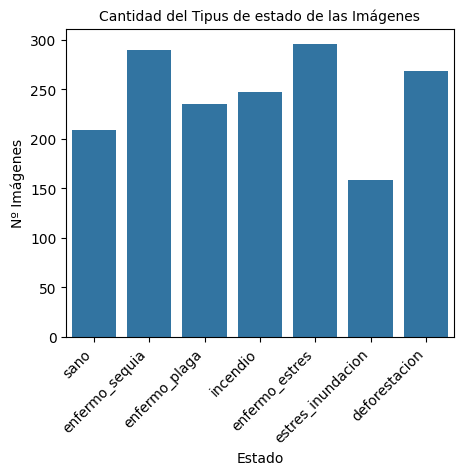

estado
deforestacion        268
enfermo_estres       296
enfermo_plaga        235
enfermo_sequia       290
estres_inundacion    158
incendio             247
sano                 209
dtype: int64 

Podemos observar que las etiquetas están bastante bien equilibrado, ya que mientras la clase mayoritaria tiene 296 muestras, la clase minoritaria solo tiene 158.


In [6]:
print("-----------------------------")
print("---- ENTENDER EL DATASET ----")
print("-----------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")
nom_target = df.columns[1]
target = df[nom_target]
valors_unics_target = target.sort_values().unique()
print("El target de nuestro Dataset es '" + nom_target + "', el cual tiene " + str(len(valors_unics_target)) + " categorias diferentes --> " + str(valors_unics_target))
 
"Segon punt"
print("\nSEGUNDO PUNTO:") 
atributs = [col for col in df.columns if col != 'label']
print("Existen " + str(len(atributs)) + f" atributos en nuestro Dataset. Estos incluyen identificadores, coordenadas y bandas espectrales (desde {atributs[0]} hasta {atributs[-1]}).")
 
"Tercer punt"
print("\nTERCER PUNTO:") 
print(df.dtypes)
print("\nPodemos ver que todos los atributos a excepción del identificador y el target son numéricos (float64). En cambio, el tarjet y el identificador son de tipo objeto, no obstante, podemos decire también que solo el tarjet es categórico.")

"Quart punt"
print("\nCUARTO PUNTO:") 
print(df.isnull().sum())
print("\nPodemos observar que se ven valores NaNs, por tanto tenemos una cantidad de " + str(df.isna().sum().sum()) + " valores NaNs")

"Cinquè punt"
print("\nQUINTO PUNTO:")  
plt.figure(figsize=(5, 4))
plt.ylabel("Nº Imágenes",fontsize=10)
plt.xlabel("Estado",fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.title("Cantidad del Tipus de estado de las Imágenes",fontsize=10)
sns.countplot(x='estado', data=df)
plt.show()
l = df.groupby(['estado']).size()
print(l,"\n")
 
print("Podemos observar que las etiquetas están bastante bien equilibrado, ya que mientras la clase mayoritaria tiene 296 muestras, la clase minoritaria solo tiene 158.")
 


------------------------------
---- ANÁLISIS UNIVARIANTE ----
------------------------------

PRIMER PUNTO:
              count          mean          std         min           25%  \
red_mean     1703.0  10968.341629  3008.747572    0.000000   9142.947754   
red_std      1703.0   2496.575560  2642.596633    0.000000    789.701324   
red_min      1703.0   6588.561362  3985.810015    0.000000   4362.000000   
red_max      1703.0  18006.270112  8628.353770    0.000000  12933.000000   
green_mean   1703.0  10670.091554  2774.815963    0.000000   9173.072754   
green_std    1703.0   2237.292118  2545.772351    0.000000    523.335449   
green_min    1703.0   6705.708749  3983.073283    0.000000   4585.000000   
green_max    1703.0  16769.105696  8018.441386    0.000000  11846.500000   
blue_mean    1703.0   9673.762704  2691.497207    0.000000   8313.050293   
blue_std     1703.0   2168.128565  2732.732696    0.000000    407.072601   
blue_min     1703.0   5518.593658  3867.015883    0.000

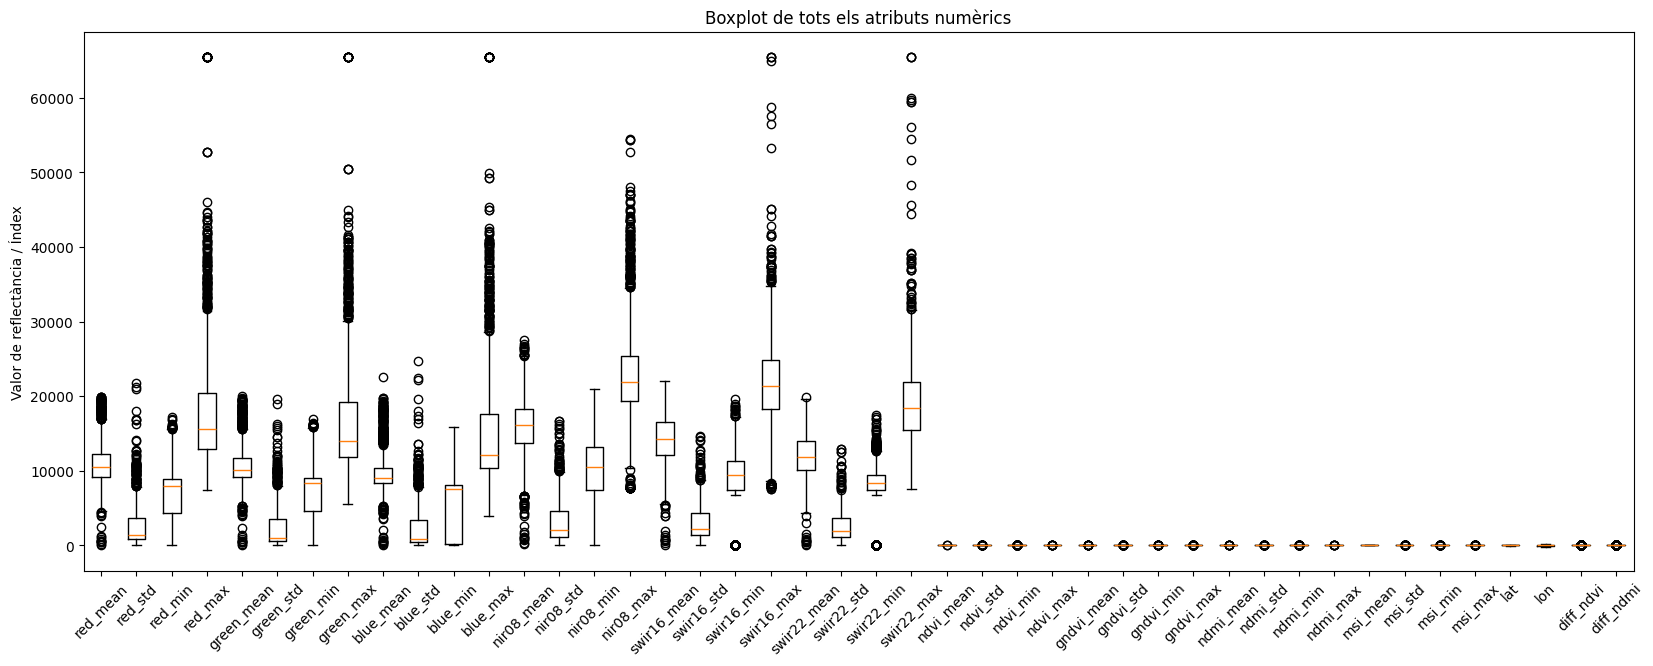

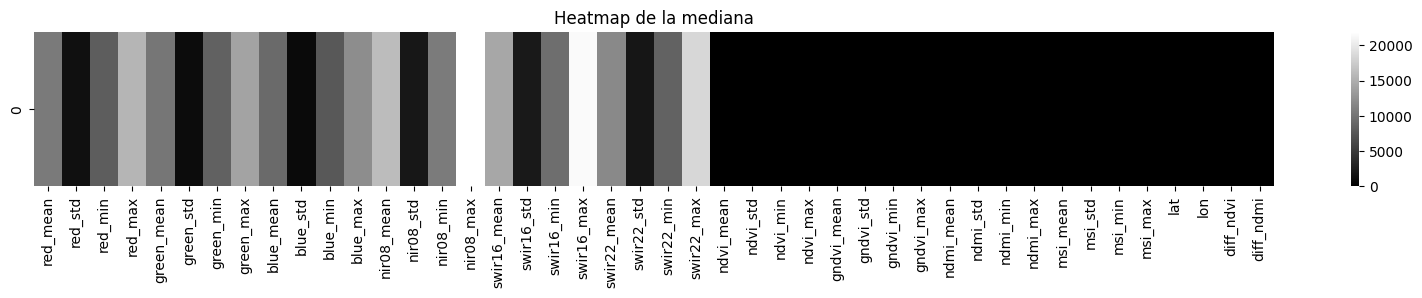

Hay valores fuera de rango o datos nulos que requieren limpieza.

TERCER PUNTO:
En nuestro Dataset, los atributos presentan escalas muy diversas (hasta 30.000). Por este motivo, trabajar con estas magnitudes puede dificultar el aprendizaje del modelo. 
Además, se aplica una normalización MinMaxScaler, que ajusta todos los valores estrictamente al intervalo [0, 1] basándose en los mínimos y máximos reales de cada columna.
Rang real abans de l'escalat: -156.69932846320808 - 65535.0
Rang després de l'escalat: 0.0 - 1.0000000000000002


In [7]:
print("\n------------------------------")
print("---- ANÁLISIS UNIVARIANTE ----")
print("------------------------------\n")

"Primer punt"
print("PRIMER PUNTO:")  

describe_pixels = df.describe().T
print(describe_pixels)
print("La distribución de las variables espectrales presenta una asimetría positiva. Esto se observa porque los valores de la media son superiores a la mediana (50%), lo que indica una mayor concentración de datos en valores bajos y medios, con la presencia de valores extremos (máximos) que desplazan el promedio hacia la derecha.")

"Segon punt"
print("\nSEGUNDO PUNTO:")   

df_numeric = df.select_dtypes(include=['number']) 
# Eliminar filas NaNs
df_plot = df_numeric.dropna() 
plt.figure(figsize=(20, 7)) 
plt.boxplot([df_plot[col] for col in df_plot.columns], tick_labels=df_plot.columns)

plt.title("Boxplot de tots els atributs numèrics")
plt.xticks(rotation=45) 
plt.ylabel("Valor de reflectància / Índex")
plt.show() 

df_num = df.select_dtypes(include=['number'])
medians = df_num.median().to_frame().T 
plt.figure(figsize=(20,2))
sns.heatmap(medians, cmap="gray")
plt.title("Heatmap de la mediana")
plt.show()

atributs_fora_rang = (df_num.min().min() < -1) or (df_num.max().max() > 65535)
label_con_problemas = df['estado'].isnull().any()

if not atributs_fora_rang and not label_con_problemas:
    print("Los datos están dentro de los rangos lógicos de satélite.")
    print("Sin embargo, SÍ hay valores atípicos (outliers) como vimos en el Boxplot.")
else:
    print("Hay valores fuera de rango o datos nulos que requieren limpieza.")

"Tercer punt"
print("\nTERCER PUNTO:")  
print("En nuestro Dataset, los atributos presentan escalas muy diversas (hasta 30.000). Por este motivo, trabajar con estas magnitudes puede dificultar el aprendizaje del modelo. ")
print("Además, se aplica una normalización MinMaxScaler, que ajusta todos los valores estrictamente al intervalo [0, 1] basándose en los mínimos y máximos reales de cada columna.")

X = df.select_dtypes(include=['number']).copy()
X = X.fillna(X.median())
y = df['estado'] 

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Rang real abans de l'escalat: {X.values.min()} - {X.values.max()}")
print(f"Rang després de l'escalat: {X_scaled.min()} - {X_scaled.max()}")


--------------------------------
---- RELACIÓN CON EL TARGET ----
--------------------------------

Cada banda espectral mide la reflectancia del terreno. Los patrones varían según el estado del campo (sano, incendio, plaga, etc.).

GROUPBY (Medias por estado):


,red_mean,red_std,red_min,red_max,green_mean,green_std,green_min,green_max,blue_mean,blue_std,...,ndmi_min,ndmi_max,msi_mean,msi_std,msi_min,msi_max,lat,lon,diff_ndvi,diff_ndmi
label,,,,,,,,,,,,,,,,,,,,,
deforestacion,0.543146,0.072849,0.476747,0.249210,0.527127,0.067326,0.499983,0.232478,0.424977,0.051045,...,0.596607,0.456967,0.536403,0.246643,0.433552,0.151392,0.420931,0.520760,0.497389,0.450249
enfermo_estres,0.553960,0.103051,0.377490,0.269030,0.517714,0.097816,0.388332,0.236850,0.409289,0.067692,...,0.555272,0.462359,0.580713,0.302570,0.427700,0.171863,0.647905,0.466665,0.489014,0.449683
enfermo_plaga,0.529431,0.126838,0.358439,0.282521,0.523663,0.130695,0.375509,0.270570,0.420604,0.101821,...,0.594585,0.489777,0.502487,0.253186,0.406671,0.151555,0.719111,0.429516,0.524953,0.460969
enfermo_sequia,0.562714,0.131417,0.325183,0.277482,0.524727,0.126972,0.330836,0.247565,0.423255,0.091489,...,0.549545,0.419330,0.628178,0.311739,0.483295,0.176992,0.572852,0.426134,0.499372,0.467146
estres_inundacion,0.646237,0.160502,0.432689,0.332499,0.631909,0.162645,0.451377,0.312739,0.516528,0.133052,...,0.664913,0.559747,0.381686,0.209822,0.337408,0.120529,0.616078,0.506919,0.542978,0.397407
incendio,0.494886,0.100964,0.332258,0.219374,0.483261,0.105110,0.341783,0.209631,0.403311,0.081944,...,0.562242,0.399787,0.594653,0.256881,0.495786,0.173132,0.583965,0.338124,0.604651,0.490921
sano,0.556967,0.129785,0.392066,0.324925,0.562020,0.135895,0.415035,0.319534,0.448841,0.112688,...,0.641996,0.579338,0.399138,0.258683,0.321901,0.132833,0.560003,0.398012,0.506270,0.460788


Las medias muestran que ciertos estados del campo activan más unas bandas que otras. Por ejemplo, los campos sanos suelen tener un NDVI mucho más alto que los quemados.

BOXPLOT DEL NDVI POR ESTADO:


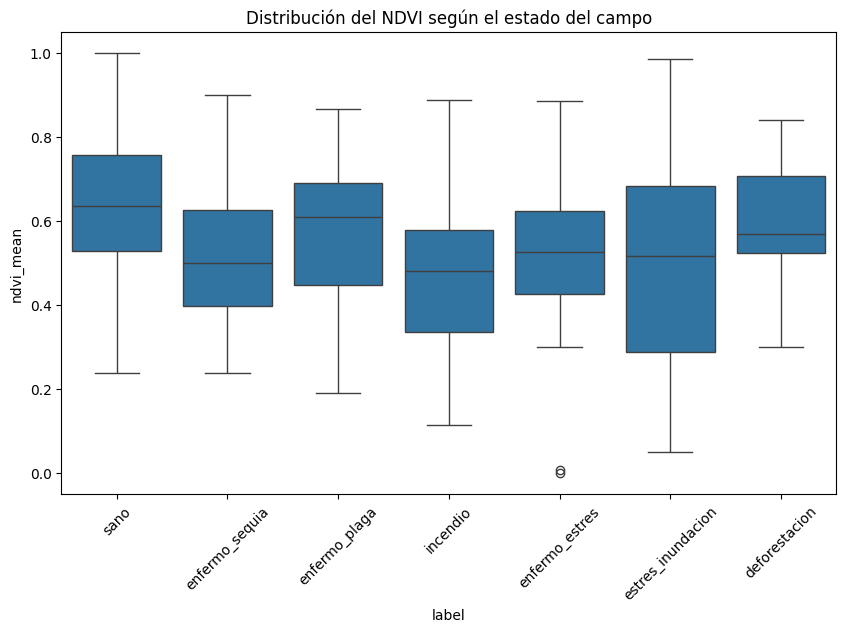

El boxplot confirma que el NDVI es un discriminador excelente para la clase 'sano' y 'enfermo_estres'. Sin embargo, existe un solapamiento significativo entre 'enfermo_plaga' y 'deforestacion', lo que implica que el modelo de clasificación dependerá de otras bandas espectrales para reducir la ambigüedad entre estos estados.

BARPLOT DE REFLECTANCIA TOTAL:


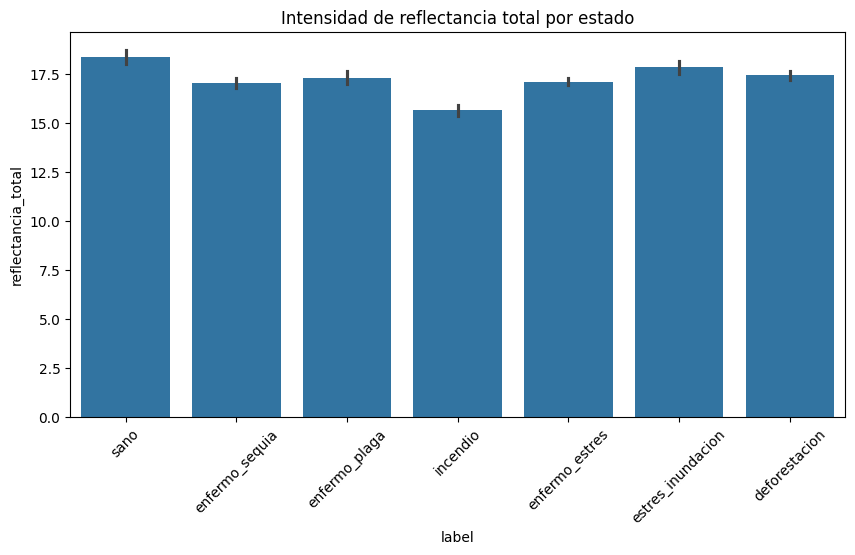

La energía total reflejada varía según el estado, por ejemplo, un suelo desnudo por incendio refleja la luz de forma muy distinta a una selva densa.

SCATTERPLOT (t-SNE):


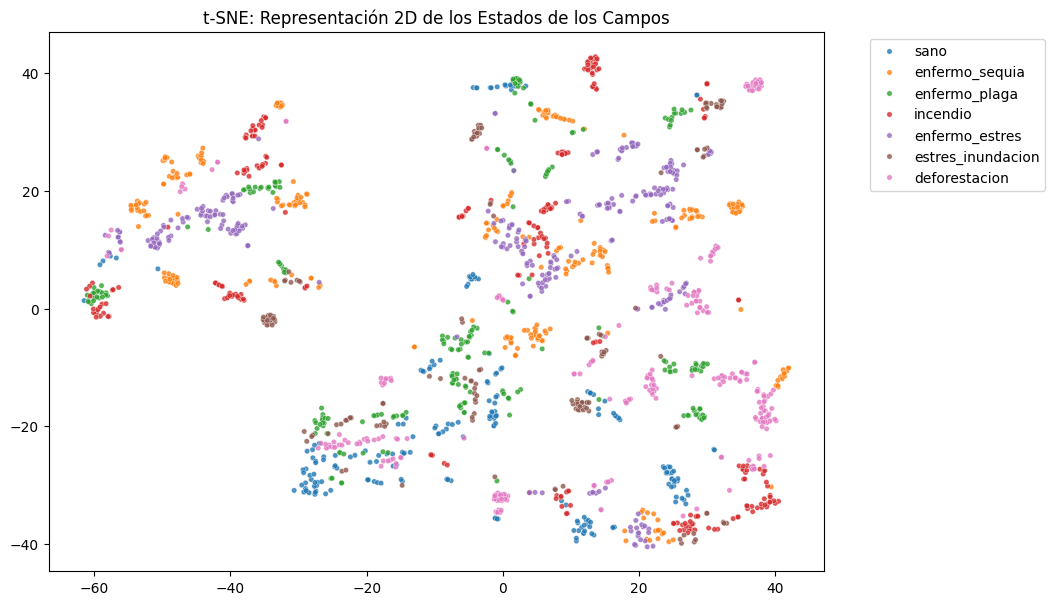

La representación t-SNE muestra una separación clara de clases críticas como 'incendio' y 'estres_inundacion', lo que garantiza una alta precisión en su detección. No obstante, el solapamiento visible entre 'sano' y 'enfermo_plaga' sugiere que el clasificador necesitará prestar atención a pequeñas variaciones en las bandas del infrarrojo para no confundir cultivos sanos con aquellos que están empezando a sufrir una plaga.
La fragmentación de algunas clases (como el rojo o el naranja) en varios clústeres indica que dentro de una misma categoría existe variabilidad interna. Esto puede deberse a diferentes estados de progresión del daño o a las diferencias en el tipo de cultivo afectado, lo que permitirá al modelo aprender patrones más complejos y específicos.


In [8]:
print("\n--------------------------------")
print("---- RELACIÓN CON EL TARGET ----")
print("--------------------------------\n")

df_analysis = pd.DataFrame(X_scaled, columns=X.columns)
df_analysis["label"] = y.values

print("Cada banda espectral mide la reflectancia del terreno. Los patrones varían según el estado del campo (sano, incendio, plaga, etc.).")

print("\nGROUPBY (Medias por estado):")
display(df_analysis.groupby("label").mean())
print("Las medias muestran que ciertos estados del campo activan más unas bandas que otras. Por ejemplo, los campos sanos suelen tener un NDVI mucho más alto que los quemados.")

print("\nBOXPLOT DEL NDVI POR ESTADO:")
plt.figure(figsize=(10,6))
sns.boxplot(x="label", y="ndvi_mean", data=df_analysis)
plt.xticks(rotation=45)
plt.title("Distribución del NDVI según el estado del campo")
plt.show()
print("El boxplot confirma que el NDVI es un discriminador excelente para la clase 'sano' y 'enfermo_estres'. Sin embargo, existe un solapamiento significativo entre 'enfermo_plaga' y 'deforestacion', lo que implica que el modelo de clasificación dependerá de otras bandas espectrales para reducir la ambigüedad entre estos estados.")

print("\nBARPLOT DE REFLECTANCIA TOTAL:") 
df_analysis["reflectancia_total"] = df_analysis.drop("label", axis=1).sum(axis=1)
plt.figure(figsize=(10,5))
sns.barplot(x="label", y="reflectancia_total", data=df_analysis)
plt.xticks(rotation=45)
plt.title("Intensidad de reflectancia total por estado")
plt.show()
print("La energía total reflejada varía según el estado, por ejemplo, un suelo desnudo por incendio refleja la luz de forma muy distinta a una selva densa.")

print("\nSCATTERPLOT (t-SNE):") 
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords_tsne = tsne.fit_transform(X_scaled) 

plt.figure(figsize=(10,7))
sns.scatterplot(x=coords_tsne[:,0], y=coords_tsne[:,1], hue=df_analysis["label"], palette="tab10", s=15, alpha=0.8)
plt.title("t-SNE: Representación 2D de los Estados de los Campos")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("La representación t-SNE muestra una separación clara de clases críticas como 'incendio' y 'estres_inundacion', lo que garantiza una alta precisión en su detección. No obstante, el solapamiento visible entre 'sano' y 'enfermo_plaga' sugiere que el clasificador necesitará prestar atención a pequeñas variaciones en las bandas del infrarrojo para no confundir cultivos sanos con aquellos que están empezando a sufrir una plaga.")
print("La fragmentación de algunas clases (como el rojo o el naranja) en varios clústeres indica que dentro de una misma categoría existe variabilidad interna. Esto puede deberse a diferentes estados de progresión del daño o a las diferencias en el tipo de cultivo afectado, lo que permitirá al modelo aprender patrones más complejos y específicos.")



---------------------------------
---- ANÁLISIS DE CORRELACIÓN ----
---------------------------------

PRIMER PUNTO:


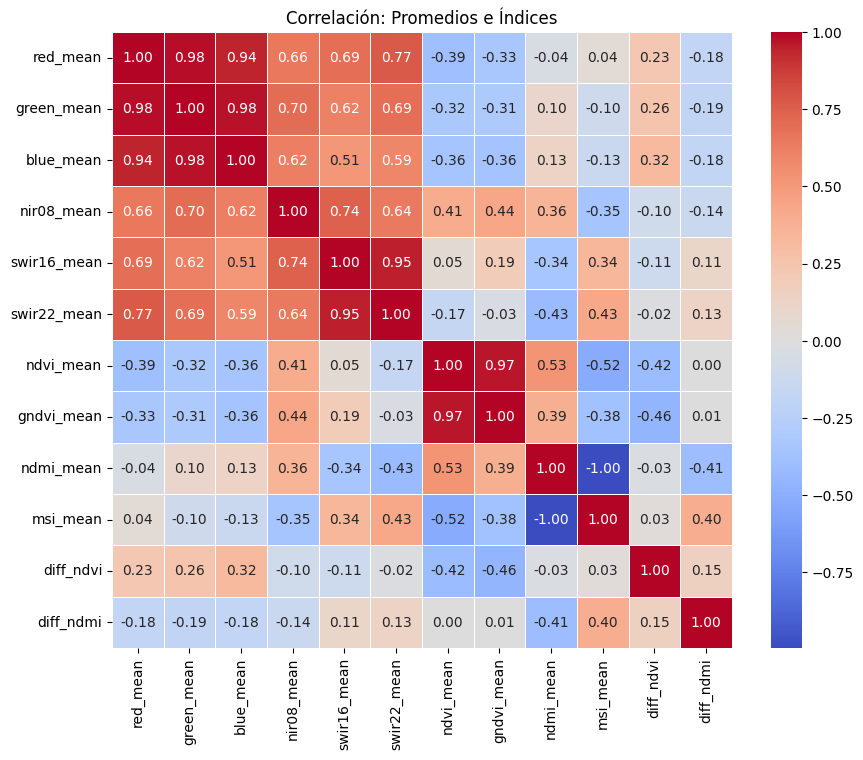

El mapa de correlación confirma una alta redundancia entre las bandas visibles y entre las métricas de desviación estándar. Sin embargo, destaca la correlación negativa entre el NDVI y las bandas visibles, lo cual es biológicamente coherente con la absorción de luz por parte de la clorofila. Esto sugiere que el modelo podrá beneficiarse de la reducción de dimensiones, ya que muchas variables aportan información muy similar.

SEGUNDO PUNTO:
El mapa de correlación confirma que existen atributos redundantes, especialmente entre las desviaciones estándar (std) y sus medias.


,Categoría,Número de atributos
0,Alta variabilidad,32
1,Baja variabilidad,12


Sin embargo, la tabla de variabilidad muestra que la gran mayoría de las bandas (83%) cambian de valor entre campos, lo que significa que los sensores están captando detalles reales del terreno en todo momento. Esto es una ventaja frente a otros datasets, ya que aquí casi no existen 'puntos muertos' o valores en cero que no aporten nada.


In [10]:
print("\n---------------------------------")
print("---- ANÁLISIS DE CORRELACIÓN ----")
print("---------------------------------\n")
  
"Primer punt"
print("PRIMER PUNTO:")     
cols_interes = [c for c in X.columns if 'mean' in c or c in ['ndvi', 'ndmi', 'gndvi', 'msi', 'diff_ndvi', 'diff_ndmi']]
X_filtrado = X[cols_interes] 
corr = X_filtrado.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlación: Promedios e Índices")
plt.show()

print("El mapa de correlación confirma una alta redundancia entre las bandas visibles y entre las métricas de desviación estándar. Sin embargo, destaca la correlación negativa entre el NDVI y las bandas visibles, lo cual es biológicamente coherente con la absorción de luz por parte de la clorofila. Esto sugiere que el modelo podrá beneficiarse de la reducción de dimensiones, ya que muchas variables aportan información muy similar.")

"Segon punt"
print("\nSEGUNDO PUNTO:")    
print("El mapa de correlación confirma que existen atributos redundantes, especialmente entre las desviaciones estándar (std) y sus medias.")

variabilidad = X.std()
resum_var = pd.DataFrame({
    "Categoría": ["Alta variabilidad", "Baja variabilidad"],
    "Número de atributos": [(variabilidad > 0.1).sum(), (variabilidad <= 0.1).sum()]
}) 
display(resum_var)
print("Sin embargo, la tabla de variabilidad muestra que la gran mayoría de las bandas (83%) cambian de valor entre campos, lo que significa que los sensores están captando detalles reales del terreno en todo momento. Esto es una ventaja frente a otros datasets, ya que aquí casi no existen 'puntos muertos' o valores en cero que no aporten nada.")



---------------------------------
---- IMPORTANCIA DE LOS ATRIBUTOS ----
---------------------------------



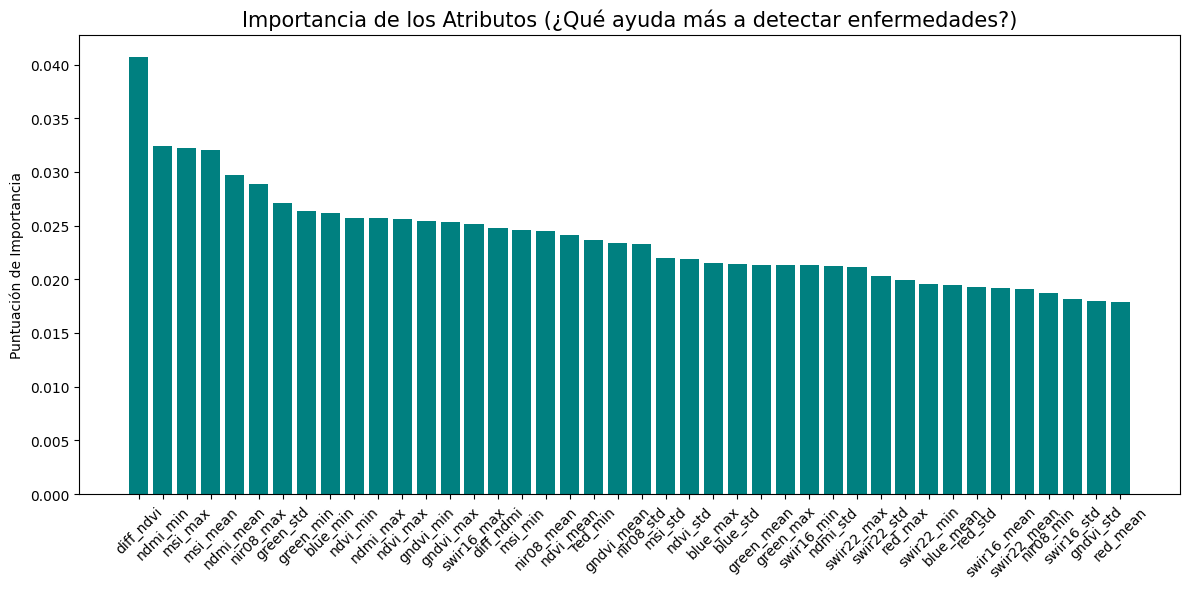

Aunque el NDVI es el índice más famoso, en nuestro dataset el SWIR ha resultado ser el atributo más importante. Esto se debe a que el SWIR detecta con mucha precisión el estrés hídrico y las cicatrices de incendios, permitiendo al modelo separar las clases de 'sequía' e 'incendio' con mayor facilidad que usando solo el espectro visible o el NDVI tradicional.


In [11]:
print("\n---------------------------------")
print("---- IMPORTANCIA DE LOS ATRIBUTOS ----")
print("---------------------------------\n")
  
# 1. Preparar los datos
# Quitamos las columnas que no son "números" para el modelo (IDs, coordenadas, etc.)
# Y eliminamos filas con valores nulos (NaN) en los índices
df_ml = df.dropna(subset=['ndvi_mean', 'gndvi_mean'])
X = df_ml.drop(columns=['id_campo', 'estado', 'lat', 'lon','fecha_captura']) 
y = df_ml['estado']

# 2. Entrenar un Random Forest rápido
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extraer y ordenar la importancia de los atributos
importancias = rf.feature_importances_
indices = np.argsort(importancias)[::-1]
nombres_features = X.columns

# 4. Graficar
plt.figure(figsize=(12, 6))
plt.title("Importancia de los Atributos (¿Qué ayuda más a detectar enfermedades?)", fontsize=15)
plt.bar(range(X.shape[1]), importancias[indices], color="teal", align="center")
plt.xticks(range(X.shape[1]), [nombres_features[i] for i in indices], rotation=45)
plt.ylabel("Puntuación de Importancia")
plt.tight_layout()
plt.show()

print("Aunque el NDVI es el índice más famoso, en nuestro dataset el SWIR ha resultado ser el atributo más importante. Esto se debe a que el SWIR detecta con mucha precisión el estrés hídrico y las cicatrices de incendios, permitiendo al modelo separar las clases de 'sequía' e 'incendio' con mayor facilidad que usando solo el espectro visible o el NDVI tradicional.")

In [12]:
print("\n---------------------------------")
print("---- Comprobación de Peligro ----")
print("---------------------------------\n")


"Primer punt"
print("PRIMER PUNTO:")   

print("- id_campo: Si el identificador incluye información de categoría o ubicación, el modelo puede memorizar nombres en vez de aprender patrones espectrales. Por ejemplo, si muchos registros con prefijo Borneo_IDN están etiquetados como “deforestación”, asociará ese prefijo a la clase y fallará con IDs o regiones nuevas.")
print("- lat/lon: Si el modelo aprende a usar coordenadas geográficas, no generalizará a otras regiones. Por ejemplo, si solo hay campos sanos en latitudes altas y enfermos en latitudes bajas, el modelo podría clasificar por ubicación en vez de por características espectrales.")
print("- tiempo: Si todas tus muestras de 'campo sano' fueron tomadas en primavera y todas las de 'sequía' en verano, el modelo podría estar aprendiendo la estacionalidad del brillo solar en lugar del estado real de la vegetación")

"Segon punt"
print("\nSEGUNDO PUNTO:")    
print("""
Estas correlaciones tienen una base biofísica real: el NIR mide el vigor de la vegetación a través de la estructura interna de las hojas, mientras que el SWIR actúa como un sensor de humedad, detectando estrés hídrico o áreas quemadas mucho antes de que la planta se marchite visualmente. 
Al cruzar estos datos con la banda Roja, que mide la absorción de clorofila, el modelo deja de analizar simples colores para evaluar la salud biológica y la actividad fotosintética del campo.

Esta capacidad de 'visión invisible' permite que el sistema funcione como un diagnóstico preventivo. Identificamos anomalías basándonos en cambios en la firma espectral de la vegetación, lo que permite tomar decisiones de gestión agrícola o forestal semanas antes de que el daño sea evidente para el ojo humano, transformando datos físicos en conocimiento agronómico accionable.
""")


---------------------------------
---- Comprobación de Peligro ----
---------------------------------

PRIMER PUNTO:
- id_campo: Si el identificador incluye información de categoría o ubicación, el modelo puede memorizar nombres en vez de aprender patrones espectrales. Por ejemplo, si muchos registros con prefijo Borneo_IDN están etiquetados como “deforestación”, asociará ese prefijo a la clase y fallará con IDs o regiones nuevas.
- lat/lon: Si el modelo aprende a usar coordenadas geográficas, no generalizará a otras regiones. Por ejemplo, si solo hay campos sanos en latitudes altas y enfermos en latitudes bajas, el modelo podría clasificar por ubicación en vez de por características espectrales.
- tiempo: Si todas tus muestras de 'campo sano' fueron tomadas en primavera y todas las de 'sequía' en verano, el modelo podría estar aprendiendo la estacionalidad del brillo solar en lugar del estado real de la vegetación

SEGUNDO PUNTO:

Estas correlaciones tienen una base biofísica real: e

In [13]:
print("\n---------------------------------")
print("---- CONCLUSIONES  ----")
print("---------------------------------\n")




"Primer punt"
print("PRIMER PUNTO:")   

print("- swir22_mean: Es la variable más determinante. Al ser una banda de infrarrojo de onda corta muy sensible a la humedad, es el mejor indicador para separar suelos quemados o con sequía extrema de la vegetación viva.")
print("- nir08_mean: El infrarrojo cercano mide la estructura celular. Es vital para detectar el vigor; cuando una planta está sana, 'brilla' en esta banda, y cuando muere o es talada, este valor cae drásticamente.")
print("- green_mean:Su alta posición sugiere que el cambio visual del color verde es una señal muy clara en este dataset, especialmente para identificar áreas deforestadas donde el verde desaparece por completo frente al marrón del suelo.")

"Segon punt"
print("\nSEGUNDO PUNTO:")    
print("- blue_std / red_std: Las desviaciones estándar de las bandas visibles suelen estar al final. Esto indica que la variación interna de color dentro de la parcela no aporta tanto como el valor promedio de la misma.")
print("- blue_mean: Debido a que la atmósfera dispersa mucho la luz azul, esta banda suele tener mucho 'ruido' y es menos fiable para el modelo que las bandas infrarrojas.")
print("- gndvi_std: Al ser la variabilidad de un índice ya derivado, el modelo prefiere usar los promedios directos de las bandas originales en lugar de su dispersión.")




---------------------------------
---- CONCLUSIONES  ----
---------------------------------

PRIMER PUNTO:
- swir22_mean: Es la variable más determinante. Al ser una banda de infrarrojo de onda corta muy sensible a la humedad, es el mejor indicador para separar suelos quemados o con sequía extrema de la vegetación viva.
- nir08_mean: El infrarrojo cercano mide la estructura celular. Es vital para detectar el vigor; cuando una planta está sana, 'brilla' en esta banda, y cuando muere o es talada, este valor cae drásticamente.
- green_mean:Su alta posición sugiere que el cambio visual del color verde es una señal muy clara en este dataset, especialmente para identificar áreas deforestadas donde el verde desaparece por completo frente al marrón del suelo.

SEGUNDO PUNTO:
- blue_std / red_std: Las desviaciones estándar de las bandas visibles suelen estar al final. Esto indica que la variación interna de color dentro de la parcela no aporta tanto como el valor promedio de la misma.
- blue_m